In [2]:
from core.lca import get_inventory_dataset, run_lca, compute_midpoint_contributions
from core.lci import INVENTORIES
from core.lcia_methods import *

In [3]:
# Brightway imports
import bw2data as bd
import bw2io as bi
import brightway2 as bw

In [4]:
import pandas as pd

In [4]:
BW_PROJECT = 'fasc' # insert your project name here
bd.projects.set_current(BW_PROJECT)
list(bd.databases)

['biosphere3',
 'ecoinvent-3.10.1-cutoff',
 'cutoff310',
 'IMAGE_SSP2L20',
 'IMAGE_SSP2L25',
 'IMAGE_SSP2L30',
 'IMAGE_SSP2L35',
 'IMAGE_SSP2L40',
 'IMAGE_SSP2M20',
 'IMAGE_SSP2M25',
 'IMAGE_SSP2M30',
 'IMAGE_SSP2M35',
 'IMAGE_SSP2M40',
 'biosphere3_spatialized_flows',
 'IMAGE_SSP2L20 regionalized',
 'IMAGE_SSP2L25 regionalized',
 'IMAGE_SSP2L30 regionalized',
 'IMAGE_SSP2L35 regionalized',
 'IMAGE_SSP2L40 regionalized',
 'IMAGE_SSP2M20 regionalized',
 'IMAGE_SSP2M25 regionalized',
 'IMAGE_SSP2M30 regionalized',
 'IMAGE_SSP2M35 regionalized',
 'IMAGE_SSP2M40 regionalized']

In [5]:
dirty = [name for name in bd.databases if bd.databases[name].get("dirty")]
dirty

[]

In [ ]:
# To export a database as a .bw2package file
#db_name = "IMAGE_SSP2L20_2026 regionalized"
#fp = bi.BW2Package.export_obj(bd.Database(db_name), folder=r"C:\bw_exports")
#print(fp)

In [ ]:
import bw2data as bd
bd.projects.set_current("fasc")

db_name = "IMAGE_SSP2L20_2026 regionalized"
code = '00013df4a1d040449bd6feb23ef7135d'

act = bd.get_activity((db_name, code))
print(act)
print(act.as_dict())

In [13]:
# Import IW+
#bw.BW2Package.import_file(r'data/IW+2.2/impact_world_plus_22_brightway2_expert_version_ei310.6af5a8392fc4c9f6116ef4d14b1e57d2.bw2package')
#bw.BW2Package.import_file(r'data/IW+2.1/impact_world_plus_21_brightway2_expert_version_ei310.5535d12bedce3770ffef004e84229fd1.bw2package')

[Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Ecosystem quality: Climate change, ecosystem quality, long term,
 Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Ecosystem quality: Climate change, ecosystem quality, short term,
 Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Human health: Climate change, human health, long term,
 Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Human health: Climate change, human health, short term,
 Brightway2 Method: IMPACT World+ Midpoint 2.1 for ecoinvent v3.10: Midpoint: Climate change, long term,
 Brightway2 Method: IMPACT World+ Midpoint 2.1 for ecoinvent v3.10: Midpoint: Climate change, short term,
 Brightway2 Method: IMPACT World+ Damage 2.1 for ecoinvent v3.10: Ecosystem quality: Fisheries impact,
 Brightway2 Method: IMPACT World+ Midpoint 2.1 for ecoinvent v3.10: Midpoint: Fossil and nuclear energy use,
 Brightway2 Method: IMPACT World+ Midpoint 2.1 for ecoinvent v3.10: Mid

In [6]:
INVENTORIES_2020_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L20 regionalized'])
INVENTORIES_2025_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L25 regionalized'])
INVENTORIES_2030_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L30 regionalized'])
INVENTORIES_2035_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L35 regionalized'])
INVENTORIES_2040_L_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2L40 regionalized'])

In [7]:
# INVENTORIES_2020_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M20 regionalized'])
# INVENTORIES_2025_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M25 regionalized'])
# INVENTORIES_2030_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M30 regionalized'])
# INVENTORIES_2035_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M35 regionalized'])
# INVENTORIES_2040_M_ds = get_inventory_dataset(INVENTORIES, database_names=['IMAGE_SSP2M40 regionalized'])

# LCA calculations per kg

In [8]:
#from core.lcia_methods import IMPACT_METHODS_EQ_damages, IMPACT_METHODS_HH_damages, IMPACT_METHODS_MIDPOINT

In [9]:
df_eq_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [11]:
df_eq_20_L['Year'] = 2020
df_hh_20_L['Year'] = 2020
df_eq_20_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_20_L['Scenario'] = 'IMAGE_SSP2L'

In [13]:
df_eq_25_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_25_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [14]:
df_eq_25_L['Year'] = 2025
df_hh_25_L['Year'] = 2025
df_eq_25_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_25_L['Scenario'] = 'IMAGE_SSP2L'

In [15]:
df_eq_30_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_30_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [16]:
df_eq_30_L['Year'] = 2030
df_hh_30_L['Year'] = 2030
df_eq_30_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_30_L['Scenario'] = 'IMAGE_SSP2L'

In [17]:
df_eq_35_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_35_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [18]:
df_eq_35_L['Year'] = 2035
df_hh_35_L['Year'] = 2035
df_eq_35_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_35_L['Scenario'] = 'IMAGE_SSP2L'

In [19]:
df_eq_40_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_EQ_damages)
df_hh_40_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_HH_damages)
#df_mp_20_L = run_lca(INVENTORIES_2020_L_ds, amount=1, lcia_methods=IMPACT_METHODS_MIDPOINTS)

In [20]:
df_eq_40_L['Year'] = 2040
df_hh_40_L['Year'] = 2040
df_eq_40_L['Scenario'] = 'IMAGE_SSP2L'
df_hh_40_L['Scenario'] = 'IMAGE_SSP2L'

In [21]:
df_eq_L = pd.concat([df_eq_20_L, df_eq_25_L, df_eq_30_L, df_eq_35_L, df_eq_40_L], ignore_index=True)
df_hh_L = pd.concat([df_hh_20_L, df_hh_25_L, df_hh_30_L, df_hh_35_L, df_hh_40_L], ignore_index=True)

In [25]:
df_eq_L = df_eq_L[['Scenario', 'Year', 'Commodity'] + [col for col in df_eq_L.columns if col not in ['Scenario', 'Year', 'Commodity']]]

In [26]:
df_hh_L = df_hh_L[['Scenario', 'Year', 'Commodity'] + [col for col in df_hh_L.columns if col not in ['Scenario', 'Year', 'Commodity']]]

In [27]:
with pd.ExcelWriter(r'results/LCA/lcia_results_per_kg_per_scenarios.xlsx') as writer:
    df_eq_L.to_excel(writer, sheet_name='Ecosystem Quality', index=False)
    df_hh_L.to_excel(writer, sheet_name='Human Health', index=False)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def plot_grouped_stage_bars_log(
    df: pd.DataFrame,
    impact_cols,
    impact_mode="sum",              # "sum" ou "each" (si each -> impact_cols doit contenir 1 colonne)
    scenario=None,
    year=None,
    metals_order=None,
    geography_order=("CA", "World"),
    stage_order=("Mining", "Refining"),
    stage_col="Reference point",
    geography_col="Geography",
    metal_col="Metal",
    scenario_col="Scenario",
    year_col="Year",
    aggfunc="sum",
    figsize=(13, 5.5),
    title_prefix="",
    yscale="symlog",                # "log" | "symlog" | "linear"
    linthresh=1e-6,                 # utile si symlog
    # style
    stage_colors=None,              # {"Mining": ..., "Refining": ...}
    hatch_map=None,                 # {"CA":"///", "World":".."}
    # layout
    bar_w=0.18,
    inner_gap=0.03,                 # gap Mining vs Refining (dans un même geo)
    geo_gap=0.14,                   # gap entre CA et World (dans un même métal)
    metal_gap=0.40,                 # espace entre métaux
    output_pdf=None,
    output_png=None,
    show=True,
):
    if stage_colors is None:
        stage_colors = {"Mining": "#1f77b4", "Refining": "#ff7f0e"}
    if hatch_map is None:
        hatch_map = {"CA": "///", "World": ".."}

    dff = df.copy()
    if scenario is not None:
        dff = dff[dff[scenario_col] == scenario]
    if year is not None:
        dff = dff[dff[year_col] == year]
    if dff.empty:
        raise ValueError("Aucune donnée après filtrage (scenario/year).")

    dff[geography_col] = dff[geography_col].replace({"GLO": "World", "Global": "World"})

    # valeur à tracer
    if impact_mode == "sum":
        dff = dff.copy()
        dff["_VAL_"] = dff[impact_cols].sum(axis=1, numeric_only=True)
        value_col = "_VAL_"
        y_label = "Sum of selected impacts"
        title = f"{title_prefix}Sum({len(impact_cols)} impacts)"
    elif impact_mode == "each":
        if len(impact_cols) != 1:
            raise ValueError("impact_mode='each' -> impact_cols doit contenir 1 colonne.")
        value_col = impact_cols[0]
        y_label = value_col
        title = f"{title_prefix}{value_col}"
    else:
        raise ValueError("impact_mode doit être 'sum' ou 'each'.")

    # ordre des métaux
    if metals_order is None:
        metals = sorted(dff[metal_col].dropna().unique().tolist())
    else:
        metals = list(metals_order)

    # agrégation
    g = (
        dff.groupby([metal_col, geography_col, stage_col], as_index=False)[value_col]
        .agg(aggfunc)
    )

    piv = g.pivot_table(
        index=metal_col,
        columns=[geography_col, stage_col],
        values=value_col,
        aggfunc=aggfunc,
        fill_value=0.0,
    )

    for geo in geography_order:
        for st in stage_order:
            if (geo, st) not in piv.columns:
                piv[(geo, st)] = 0.0

    piv = piv.reindex(metals).fillna(0.0)

    # positions x (on construit un “cluster” par métal)
    n_geo = len(geography_order)
    n_st = len(stage_order)

    width_geo = n_st * bar_w + (n_st - 1) * inner_gap
    width_cluster = n_geo * width_geo + (n_geo - 1) * geo_gap

    x0 = np.arange(len(metals)) * (width_cluster + metal_gap)
    centers = x0 + width_cluster / 2

    fig, ax = plt.subplots(figsize=figsize)

    for i_m, metal in enumerate(metals):
        base = x0[i_m]

        for i_g, geo in enumerate(geography_order):
            geo_left = base + i_g * (width_geo + geo_gap)

            for i_s, st in enumerate(stage_order):
                x = geo_left + i_s * (bar_w + inner_gap)
                h = float(piv.loc[metal, (geo, st)])

                ax.bar(
                    x,
                    h,
                    width=bar_w,
                    color=stage_colors.get(st, None),
                    hatch=hatch_map.get(geo, ""),
                    edgecolor="black",
                    linewidth=0.3,
                )

    ax.set_xticks(centers)
    ax.set_xticklabels(metals, rotation=45, ha="right")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

    if yscale == "log":
        ax.set_yscale("log")
    elif yscale == "symlog":
        ax.set_yscale("symlog", linthresh=linthresh)

    # légendes (compactes)
    stage_handles = [Patch(facecolor=stage_colors[st], edgecolor="black", label=st) for st in stage_order]
    geo_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatch_map.get(geo, ""), label=geo) for geo in geography_order]

    leg1 = ax.legend(handles=stage_handles, title="Stage", loc="upper left", fontsize=9, title_fontsize=9)
    ax.add_artist(leg1)
    ax.legend(handles=geo_handles, title="Geography", loc="upper left", bbox_to_anchor=(0, 0.72), fontsize=9, title_fontsize=9)

    fig.tight_layout()

    if output_pdf:
        if not output_pdf.lower().endswith(".pdf"):
            output_pdf += ".pdf"
        fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
    if output_png:
        if not output_png.lower().endswith(".png"):
            output_png += ".png"
        fig.savefig(output_png, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, piv

In [19]:
def plot_percent_stacked_stage_bars(
    df: pd.DataFrame,
    impact_cols,
    impact_mode="sum",
    scenario=None,
    year=None,
    metals_order=None,
    geography_order=("CA", "World"),
    stage_order=("Mining", "Refining"),
    stage_col="Reference point",
    geography_col="Geography",
    metal_col="Metal",
    scenario_col="Scenario",
    year_col="Year",
    aggfunc="sum",
    figsize=(13, 5.2),
    title_prefix="",
    stage_colors=None,
    hatch_map=None,          # hatch pour distinguer CA/World (optionnel ici)
    bar_w=0.35,
    geo_gap=0.12,
    output_pdf=None,
    output_png=None,
    show=True,
):
    if stage_colors is None:
        stage_colors = {"Mining": "#1f77b4", "Refining": "#ff7f0e"}
    if hatch_map is None:
        hatch_map = {"CA": "///", "World": ".."}

    dff = df.copy()
    if scenario is not None:
        dff = dff[dff[scenario_col] == scenario]
    if year is not None:
        dff = dff[dff[year_col] == year]
    if dff.empty:
        raise ValueError("Aucune donnée après filtrage (scenario/year).")

    dff[geography_col] = dff[geography_col].replace({"GLO": "World", "Global": "World"})

    if impact_mode == "sum":
        dff = dff.copy()
        dff["_VAL_"] = dff[impact_cols].sum(axis=1, numeric_only=True)
        value_col = "_VAL_"
        title = f"{title_prefix}Stage share (100%) — Sum({len(impact_cols)} impacts)"
    elif impact_mode == "each":
        if len(impact_cols) != 1:
            raise ValueError("impact_mode='each' -> impact_cols doit contenir 1 colonne.")
        value_col = impact_cols[0]
        title = f"{title_prefix}Stage share (100%) — {value_col}"
    else:
        raise ValueError("impact_mode doit être 'sum' ou 'each'.")

    if metals_order is None:
        metals = sorted(dff[metal_col].dropna().unique().tolist())
    else:
        metals = list(metals_order)

    g = (
        dff.groupby([metal_col, geography_col, stage_col], as_index=False)[value_col]
        .agg(aggfunc)
    )
    piv = g.pivot_table(
        index=metal_col,
        columns=[geography_col, stage_col],
        values=value_col,
        aggfunc=aggfunc,
        fill_value=0.0,
    )

    for geo in geography_order:
        for st in stage_order:
            if (geo, st) not in piv.columns:
                piv[(geo, st)] = 0.0

    piv = piv.reindex(metals).fillna(0.0)

    # convertir en %
    pct = piv.copy()
    for geo in geography_order:
        total = sum(pct[(geo, st)] for st in stage_order)
        # éviter division par 0
        total = total.replace(0, np.nan)
        for st in stage_order:
            pct[(geo, st)] = 100 * (pct[(geo, st)] / total)
    pct = pct.fillna(0.0)

    # positions x : 2 barres par métal (CA, World)
    x = np.arange(len(metals))
    offsets = np.linspace(-(len(geography_order) - 1) / 2, (len(geography_order) - 1) / 2, len(geography_order)) * (bar_w + geo_gap)

    fig, ax = plt.subplots(figsize=figsize)

    for j, geo in enumerate(geography_order):
        bottom = np.zeros(len(x), dtype=float)
        for st in stage_order:
            heights = pct[(geo, st)].to_numpy(dtype=float)
            ax.bar(
                x + offsets[j],
                heights,
                width=bar_w,
                bottom=bottom,
                color=stage_colors.get(st, None),
                hatch=hatch_map.get(geo, ""),
                edgecolor="black",
                linewidth=0.3,
            )
            bottom += heights

    ax.set_xticks(x)
    ax.set_xticklabels(metals, rotation=45, ha="right")
    ax.set_ylabel("Share of stage (%)")
    ax.set_ylim(0, 100)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

    stage_handles = [Patch(facecolor=stage_colors[st], edgecolor="black", label=st) for st in stage_order]
    geo_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatch_map.get(geo, ""), label=geo) for geo in geography_order]

    leg1 = ax.legend(handles=stage_handles, title="Stage", loc="upper left", fontsize=9, title_fontsize=9)
    ax.add_artist(leg1)
    ax.legend(handles=geo_handles, title="Geography", loc="upper left", bbox_to_anchor=(0, 0.72), fontsize=9, title_fontsize=9)

    fig.tight_layout()

    if output_pdf:
        if not output_pdf.lower().endswith(".pdf"):
            output_pdf += ".pdf"
        fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
    if output_png:
        if not output_png.lower().endswith(".png"):
            output_png += ".png"
        fig.savefig(output_png, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, pct


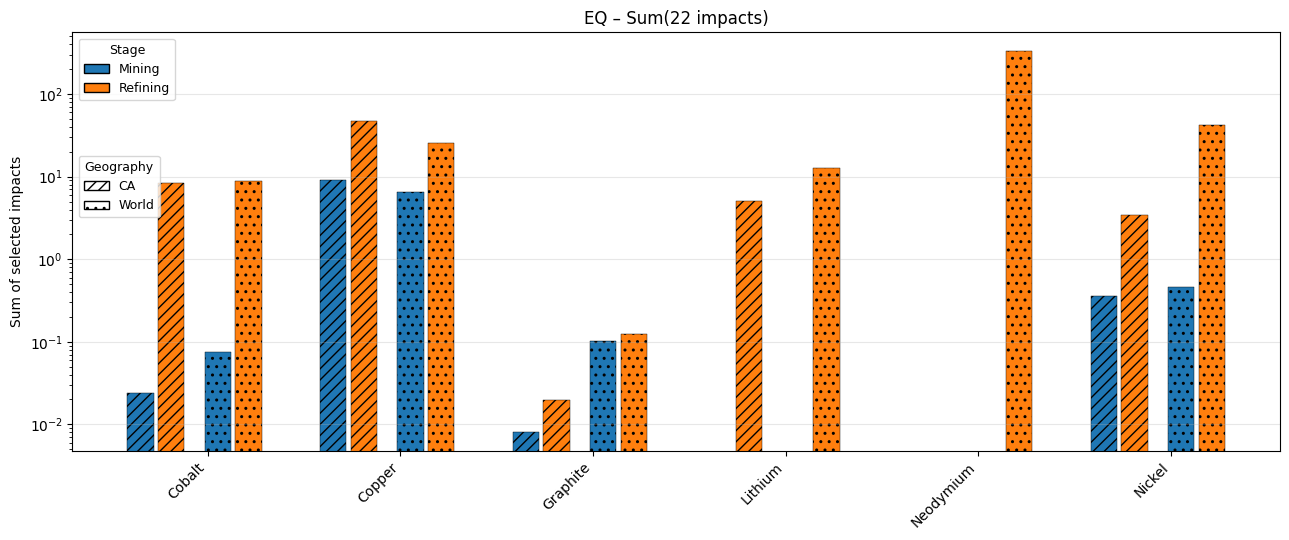

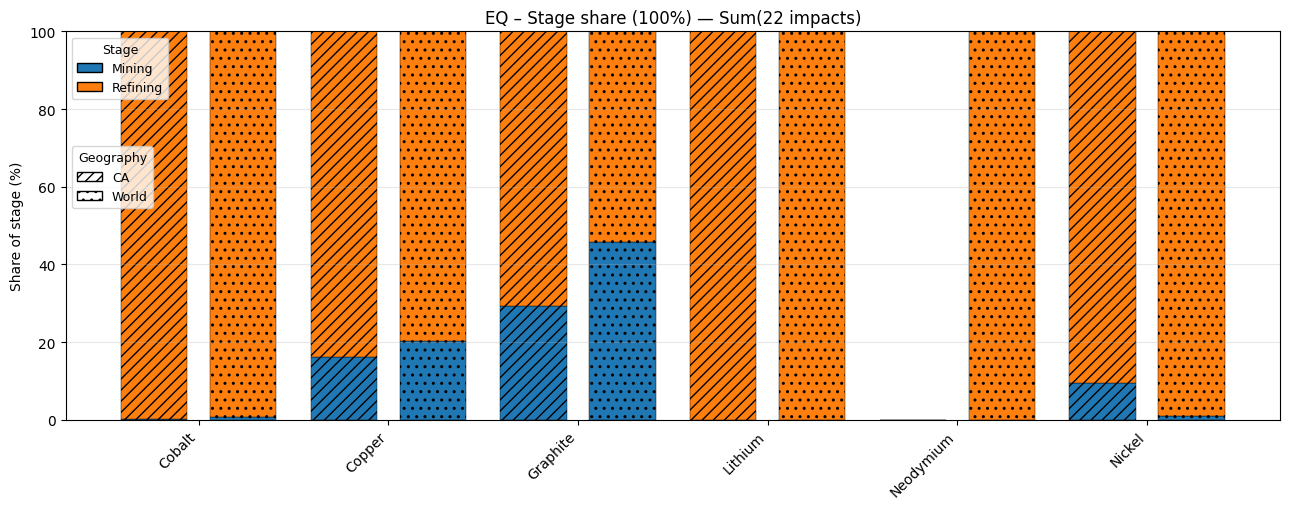

(<Figure size 1300x520 with 1 Axes>,
 Geography               CA                  World            
 Reference point     Mining    Refining     Mining    Refining
 Metal                                                        
 Cobalt            0.286129   99.713871   0.843817   99.156183
 Copper           16.159103   83.840897  20.430261   79.569739
 Graphite         29.311831   70.688169  45.735180   54.264820
 Lithium           0.000000  100.000000   0.000000  100.000000
 Neodymium         0.000000    0.000000   0.000000  100.000000
 Nickel            9.494010   90.505990   1.079347   98.920653)

In [22]:
path = "results/LCA/lcia_results_per_kg_per_scenarios.xlsx"

df_eq = pd.read_excel(path, sheet_name="Ecosystem Quality")
df_hh = pd.read_excel(path, sheet_name="Human Health")

meta = {"Scenario", "Year", "Metal", "Geography", "Reference point", "Commodity"}
impact_cols_eq = [c for c in df_eq.columns if c not in meta and pd.api.types.is_numeric_dtype(df_eq[c])]

# 1) Absolu (symlog) – grouped (Mining vs Refining côte à côte)
plot_grouped_stage_bars_log(
    df_eq,
    impact_cols=impact_cols_eq,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="EQ – ",
    yscale="log",
    linthresh=1e-6,
    output_pdf="results/LCA/EQ_2020_log.pdf",
    #output_png="EQ_sum_2020_grouped_symlog.png",
)

# 2) Relatif (100%) – stacked en %
plot_percent_stacked_stage_bars(
    df_eq,
    impact_cols=impact_cols_eq,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="EQ – ",
    output_pdf="results/LCA/EQ_2020_pct.pdf",
    #output_png="EQ_sum_2020_stage_share_100pct.png",
)

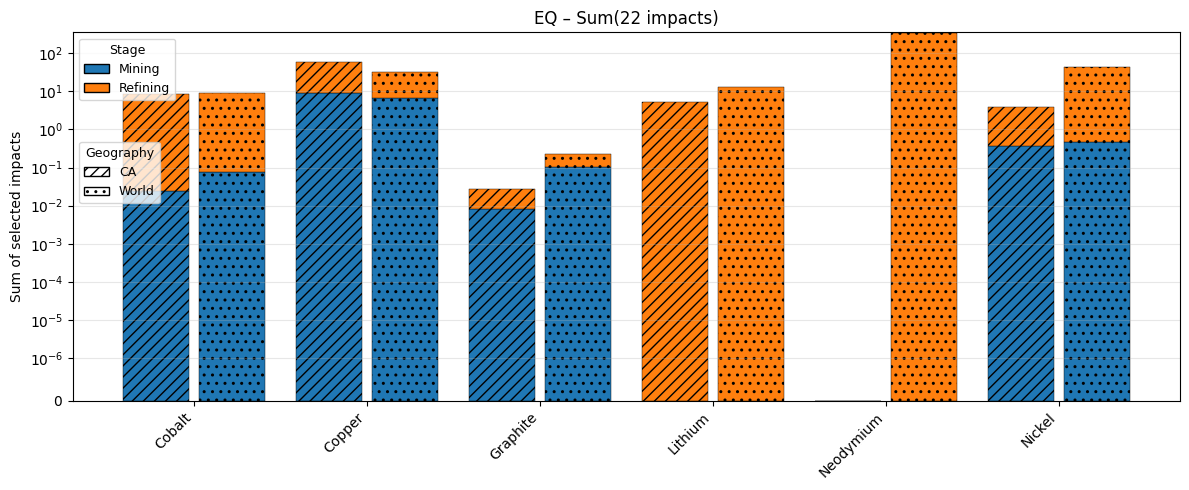

{'SUM': (<Figure size 1200x500 with 1 Axes>,
  <Axes: title={'center': 'EQ – Sum(22 impacts)'}, ylabel='Sum of selected impacts'>)}

In [15]:
path = "results/LCA/lcia_results_per_kg_per_scenarios.xlsx"

df_eq = pd.read_excel(path, sheet_name="Ecosystem Quality")
df_hh = pd.read_excel(path, sheet_name="Human Health")

meta = {"Scenario", "Year", "Metal", "Geography", "Reference point", "Commodity"}
impact_cols_eq = [c for c in df_eq.columns if c not in meta and pd.api.types.is_numeric_dtype(df_eq[c])]
impact_cols_hh = [c for c in df_hh.columns if c not in meta and pd.api.types.is_numeric_dtype(df_hh[c])]

plot_stacked_stage_bars_by_metal_log(
    df_eq,
    impact_cols=impact_cols_eq,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="EQ – ",
    yscale="symlog",
    linthresh=1e-6,  # ajuste si besoin
    output_pdf="results/LCA/stacked_EQ_sum_2020_symlog.pdf",
    show=True,
)

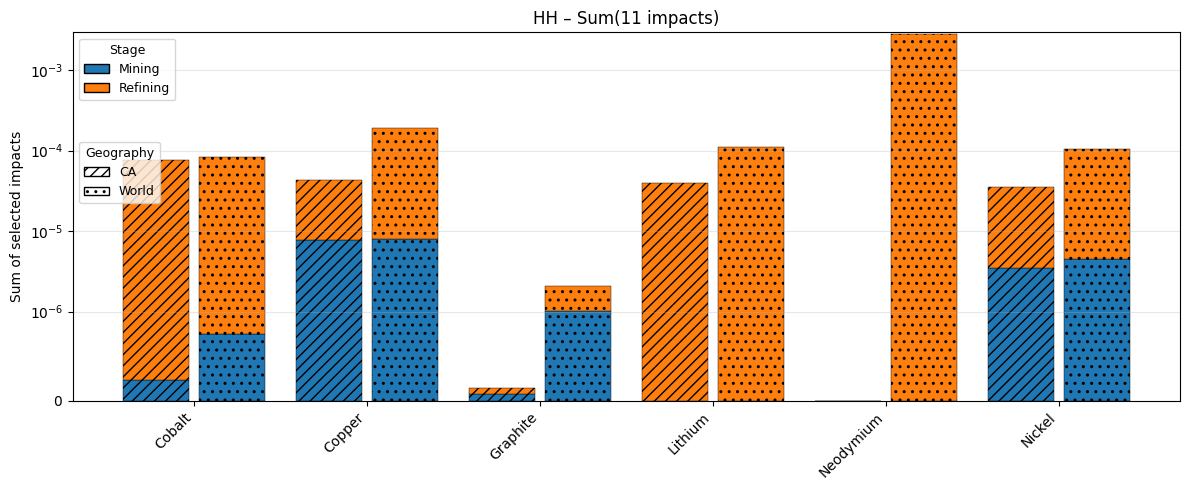

{'SUM': (<Figure size 1200x500 with 1 Axes>,
  <Axes: title={'center': 'HH – Sum(11 impacts)'}, ylabel='Sum of selected impacts'>)}

In [16]:
plot_stacked_stage_bars_by_metal_log(
    df_hh,
    impact_cols=impact_cols_hh,
    impact_mode="sum",
    scenario="IMAGE_SSP2L",
    year=2020,
    title_prefix="HH – ",
    yscale="symlog",
    linthresh=1e-6,  # ajuste si besoin
    output_pdf="results/LCA/stacked_HH_sum_2020_symlog.pdf",
    show=True,
)

# Extract production and demand data

In [ ]:
demand_df = pd.read_excel(r'data/data_lci.xlsx', sheet_name='DEMAND')
lci_demand = pd.read_excel(r'data/data_lci.xlsx', sheet_name='lci_demand')

In [ ]:
year = [2025, 2030, 2035, 2040]
demand_df = demand_df[demand_df['Year'].isin(year)]

In [ ]:
df_demand_agg = (demand_df
    .groupby(["Scenario", "Year", "Metal"])["Metal_demand_t"]
    .sum()
    .reset_index()
)


In [ ]:
df_demand_agg['Metal_demand_kg'] = df_demand_agg['Metal_demand_t'] * 1e3

In [ ]:
df_demand_cm = df_demand_agg[df_demand_agg['Scenario'] == 'Current Measures']
df_demand_nz = df_demand_agg[df_demand_agg['Scenario'] == 'Canada Net-zero']

In [ ]:
df_demand_agg

In [ ]:
lci_demand

In [ ]:
#lci_demand.to_csv(r'lci_demand.csv', index=False)
#df_demand_agg.to_csv(r'df_demand_agg.csv', index=False)

# LCA calculations

In [ ]:
from core.lca import setup_activities, run_scenario_lca

In [ ]:
lci_map = setup_activities(lci_demand)

In [ ]:
lci_map

In [ ]:
import numpy as np
import brightway2 as bw
import pandas as pd
from brightway2 import Database
from brightway2 import LCA
import numpy as np

def run_scenario_lca(df_demand_agg, activities_dict, lcia_methods):
    """
    Compute scaled LCA results for each row in df_demand_agg.
    df_demand_agg must contain:
        scenario, year, metal, metal_demand_kg
    """

    results = []

    for idx, row in df_demand_agg.iterrows():
        scenario = row["Scenario"]
        year = str(row["Year"])
        metal = row["Metal"]
        qty = float(row["Metal_demand_kg"])

        key = (scenario, year, metal)
        activity = activities_dict.get(key, None)

        impact_results = {}

        if activity is None:
            for m in lcia_methods:
                impact_results[m[2]] = np.nan

        else:
            try:
                lca = LCA({activity: qty}, lcia_methods[0])
                lca.lci()

                for method in lcia_methods:
                    lca.switch_method(method)
                    lca.lcia()
                    impact_results[method[2]] = lca.score

            except:
                for m in lcia_methods:
                    impact_results[m[2]] = np.nan

        results.append({
            "Scenario": scenario,
            "Year": year,
            "Metal": metal,
            "Demand_kg": qty,
            **impact_results
        })

    return pd.DataFrame(results)

In [ ]:
df_demand_lca = run_scenario_lca(df_demand_agg, lci_map, lcia_methods=IW_EP)

In [ ]:
df_demand_lca

In [ ]:
df_demand_lca.to_csv(r'results/LCA/df_demand_lca.csv', index=False)

In [ ]:
from utils.visualisations import plot_lca_stackplots_by_scenario
from utils.constants import selected_metal_colors

In [ ]:
fig_cm = plot_lca_stackplots_by_scenario(
    df_demand_lca,
    scenario="Current Measures",
    impact_cols=["Total human health", "Total ecosystem quality"],
    color_map=selected_metal_colors,
    group_small_metals=False,   # ← NO aggregation
    figsize=(11, 7),
    savepath="results/LCA/current_measures_ep"
)


In [ ]:
fig_nz = plot_lca_stackplots_by_scenario(
    df_demand_lca,
    scenario="Canada Net-zero",
    impact_cols=["Total human health", "Total ecosystem quality"],
    color_map=selected_metal_colors,
    group_small_metals=False,   # ← NO aggregation
    figsize=(11, 7),
    savepath="results/LCA/current_measures_nz"
)